# No Flux in 2D Domain

## Setup

### Liberaries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import os


### Import custom functions 

In [2]:
from sources.simulation import *
from sources.plotting import *
from sources.analysis import *
from sources.models import *
from sources.data_storage import *

### Initialization

In [3]:

#defind variables

n_parts = 100000
# n_parts = 10000000

T = 2
dt = 0.01

n_steps = int(T/ dt)
epsilon = np.sqrt(dt)

#set the boundries
bounds = ((0, 1), (0, 1))

#this is from 1D problem. later I can define functions for 2D domain similar to 1D
#drift and diffusion as functions
# b = lambda x, t=None: constant_drift(x, t, value=1)
# sigma = lambda x, t=None: constant_diffusion(x, t, value=1)

b = np.array([1.5, 1.0])
sigma = np.eye(2)


### Initial distribution

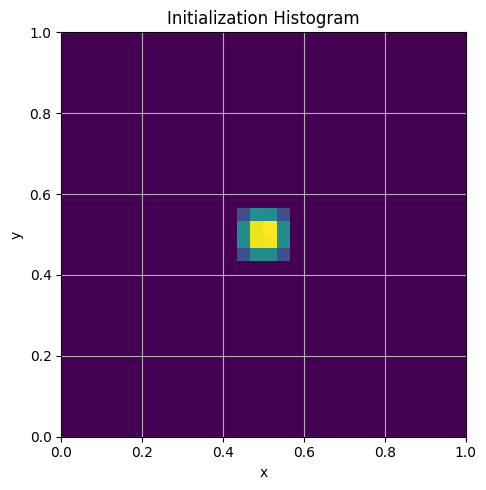

In [4]:

X_0 = np.column_stack([np.random.uniform(.45,.55, n_parts)
                       , np.random.uniform(.45,.55, n_parts)])


fig, ax = plt.subplots(figsize=(5, 5))
plot_histogram_2d(X_0, 30, ax=ax, title="Initialization Histogram", limits=bounds)

plt.tight_layout()
plt.show()

## Experiments

### Compore solutions with reflection, rejection and theta ($\theta =0.5$) boundary conditions

In [5]:


X_ref = numerical_solution(method=euler_maruyama_2d, X_0=X_0, dt=dt, n_steps=n_steps
                                                     , b=b, sigma=sigma, boundary_type="reflection"
                                                     , boundaries=bounds)

X_rej  = numerical_solution(method=euler_maruyama_2d, X_0=X_0, dt=dt, n_steps=n_steps, b=b, sigma=sigma
                                                     , boundary_type="rejection", boundaries=bounds)



### Plot the numerical and exact solutions

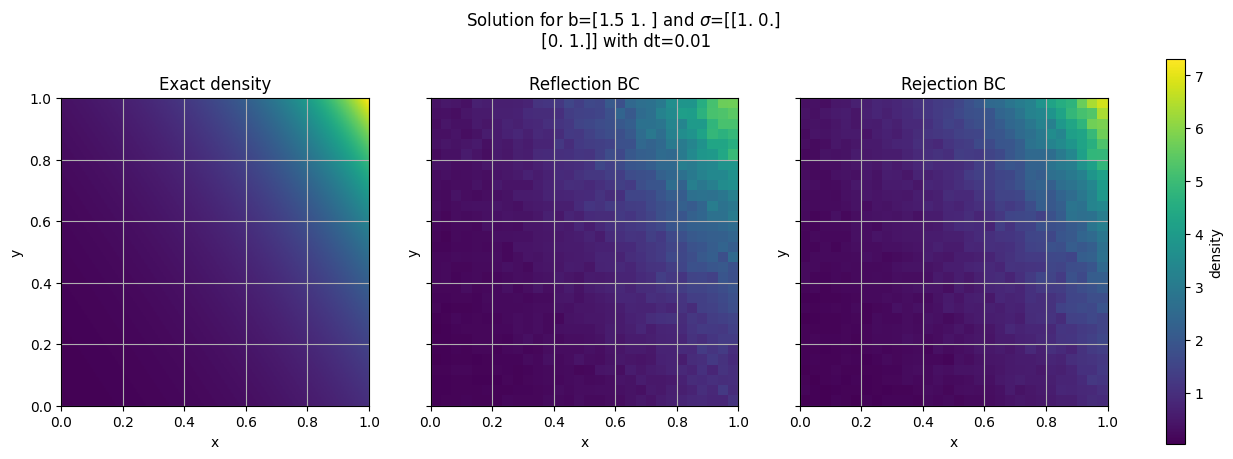

In [6]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

bins = 30
cmap = plt.get_cmap()

# compute the true solution
x_plot = np.linspace(bounds[0][0], bounds[0][1], 200)
y_plot = np.linspace(bounds[1][0], bounds[1][1], 200)

x_mesh, y_mesh = np.meshgrid(x_plot, y_plot, indexing="ij")

p_exact = stationary_solution_2d(x_mesh, y_mesh, b, sigma, bounds)

# compute numerical densities only for colorbar scale
p_ref_scale, _, _ = np.histogram2d(X_ref[:, 0], X_ref[:, 1], bins=bins, range=bounds, density=True)

p_rej_scale, _, _ = np.histogram2d(X_rej[:, 0], X_rej[:, 1], bins=bins, range=bounds, density=True)

# shared colorbar scale
colorbar_values = get_colorbar_values_2d([p_exact, p_ref_scale, p_rej_scale])

# plot
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)

fig.suptitle(fr"Solution for b={b} and $\sigma$={sigma} with {dt=}")

plot_density_2d(p_exact, bounds, ax=ax[0], title="Exact density", colorbar_values=colorbar_values
                ,cmap=cmap)

plot_histogram_2d(X=X_ref, bins=bins, ax=ax[1], title="Reflection BC", density=True, limits=bounds
                  , colorbar_values=colorbar_values, cmap=cmap)

plot_histogram_2d(X=X_rej, bins=bins, ax=ax[2], title="Rejection BC", density=True, limits=bounds
                  , colorbar_values=colorbar_values, cmap=cmap)

# shared colorbar
vmin, vmax = colorbar_values
mappable = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)

fig.colorbar(mappable, ax=ax, label="density", fraction=0.05, pad=0.05)

plt.show()

## Same in Disk Domain

### Initialization

In [7]:

#defind variables

n_parts = 100000
# n_parts = 10000000

T = 2
dt = 0.01

n_steps = int(T/ dt)
epsilon = np.sqrt(dt)



center = np.array([0.0, 0.0])
radius = 1


boundary = lambda theta: disk_boundary(radius=radius, theta=theta)

b = np.array([1.0, 0.0])
sigma = np.eye(2)


### Plot domain

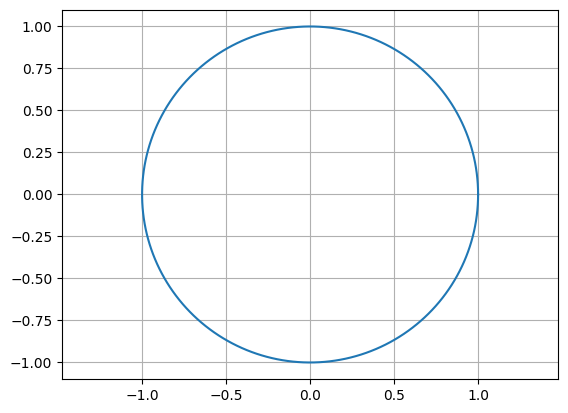

In [8]:
theta = np.linspace(0, 2*np.pi, 200)

x_boundary, y_boundary = boundary(theta)

center = np.array([0.0, 0.0])
radius = 1.0

plt.plot(x_boundary, y_boundary)
plt.axis("equal")
plt.grid(True)
plt.show()

### Inital distribution

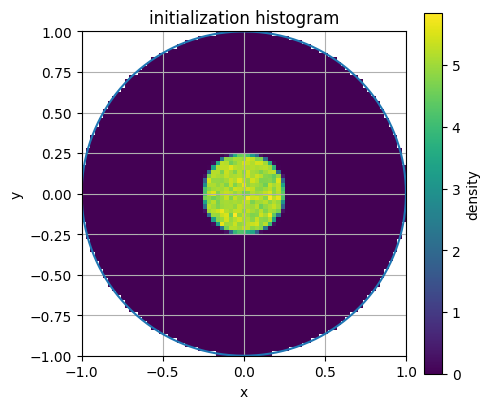

In [9]:
bins = 75

X_0 = initialize_disk(n_parts)

p_scale, _, _ = histogram_density_disk(X_0, radius=radius, bins=bins)
colorbar_values = get_colorbar_values_2d([p_scale])

fig, ax = plt.subplots(figsize=(5, 5))
plot_histogram_disk(X_0, radius=radius, bins=bins, ax=ax, title="initialization histogram"
                    , colorbar_values=colorbar_values, cmap=cmap)

vmin, vmax = colorbar_values
mappable = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
fig.colorbar(mappable, ax=ax, label="density", fraction=0.05, pad=0.05)

plt.tight_layout()
plt.show()

### Simulate Eular-Maruyama steps in disk domain

In [10]:


X_ref = numerical_solution(method=euler_maruyama_2d, X_0=X_0, dt=dt, n_steps=n_steps
                                                     , b=b, sigma=sigma, boundary_type="reflection"
                                                     , boundaries=("disk", radius))

X_rej  = numerical_solution(method=euler_maruyama_2d, X_0=X_0, dt=dt, n_steps=n_steps, b=b
                                                    , sigma=sigma, boundary_type="rejection"
                                                    , boundaries=("disk", radius))



### Plot numerical solutions

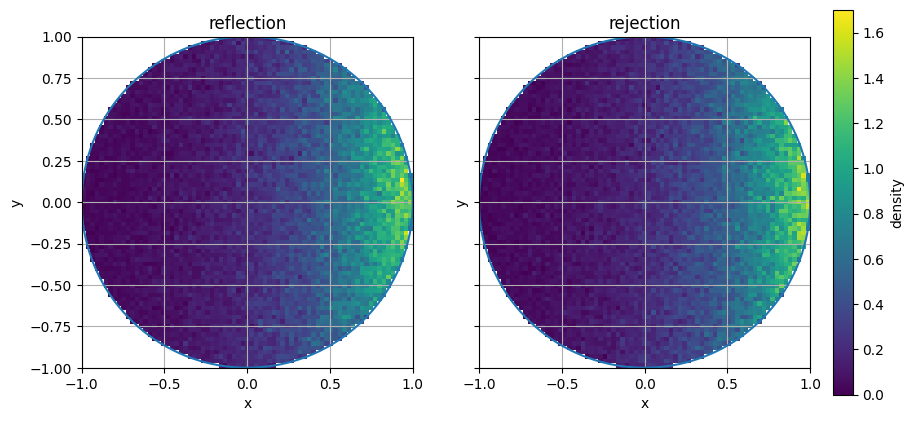

In [11]:
p_ref_scale, _, _ = histogram_density_disk(X_ref, radius=radius, bins=bins)
p_rej_scale, _, _ = histogram_density_disk(X_rej, radius=radius, bins=bins)
colorbar_values = get_colorbar_values_2d([p_ref_scale, p_rej_scale])

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

plot_histogram_disk(X_ref, radius=radius, bins=bins, ax=ax[0], title="reflection", colorbar_values=colorbar_values, cmap=cmap)
plot_histogram_disk(X_rej, radius=radius, bins=bins, ax=ax[1], title="rejection", colorbar_values=colorbar_values, cmap=cmap)

vmin, vmax = colorbar_values
mappable = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
fig.colorbar(mappable, ax=ax.ravel().tolist(), label="density", fraction=0.03, pad=0.03)

plt.show()